# DS108 - EDA trực quan hóa dữ liệu mưa

Notebook này là bản **EDA cuối cùng** cho bộ dữ liệu `feature_engineered_data.csv`.

Phạm vi:

- Chỉ tập trung vào **Exploratory Data Analysis**.
- Không train model.
- Không chọn lọc đặc trưng cuối cùng.
- Không impute biến mục tiêu `PRCP`.
- Không xuất file CSV.
- Rule ngày mưa đồng bộ với model cuối: **PRCP >= 0.1 mm**.

Feature selection sẽ được thực hiện ở file riêng.

In [21]:
# =============================================================================
# 0. Imports & Configuration
# =============================================================================

from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.8),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

# Project path
CURRENT_DIR = Path.cwd()
BASE_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() in {"notebooks", "src"} else CURRENT_DIR
DATA_PATH = BASE_DIR / "data" / "features" / "feature_engineered_data.csv"

# Final modeling rule
RAIN_THRESHOLD = 0.1

# Time split used by the final model
TRAIN_END = pd.Timestamp("2023-01-01")
VALID_END = pd.Timestamp("2024-01-01")

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

STATION_NAME = {
    "48825099999": "Ha Dong",
    "48845099999": "Vinh",
    "48863099999": "Quang Ngai",
    "48877099999": "Nha Trang",
    "48914099999": "Ca Mau",
}

RAIN_COLOR = "#3182BD"
DRY_COLOR = "#BDBDBD"
ACCENT_COLOR = "#31A354"
ORANGE_COLOR = "#E6550D"

print("BASE_DIR :", BASE_DIR)
print("DATA_PATH:", DATA_PATH)

BASE_DIR : c:\Users\Laptop\PycharmProjects\DS108
DATA_PATH: c:\Users\Laptop\PycharmProjects\DS108\data\features\feature_engineered_data.csv


In [22]:
# =============================================================================
# Helper functions
# =============================================================================

def clean_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=12, fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    sns.despine(ax=ax)
    return ax


def display_section_title(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def infer_feature_group(col: str) -> str:
    lower = col.lower()

    if col in {"STATION", "time", "DATE", "station_name", "month_name"}:
        return "metadata_time"
    if lower in {"year", "month", "day", "split", "rain_status", "prcp_label"}:
        return "eda_helper"
    if col in {"PRCP", "target_1stage_prcp_mm", "target_stage1_rain_label",
               "target_stage2_prcp_log1p", "PRCP_impute"}:
        return "target_or_auxiliary"
    if col in {"LATITUDE", "LONGITUDE", "ELEVATION"}:
        return "location"
    if col in {"TEMP", "DEWP", "WDSP", "STP", "SLP", "VISIB"}:
        return "gsod_surface"
    if lower in {"u10", "v10", "t2m", "d2m", "sp", "msl", "z", "lsm", "sst"}:
        return "era5_single_level"
    if "_500" in lower:
        return "era5_pressure_500hpa"
    if "_850" in lower:
        return "era5_pressure_850hpa"
    if any(token in lower for token in ["lag", "rolling", "past", "3d", "7d", "14d", "30d"]):
        return "lag_rolling"
    if any(token in lower for token in ["day_sin", "day_cos", "month_sin", "month_cos"]):
        return "temporal_cyclical"
    if any(token in lower for token in ["dew_point", "lapse", "convection"]):
        return "thermodynamic"
    if any(token in lower for token in ["wind", "shear", "du_", "dv_", "ageostrophic"]):
        return "wind_dynamics"
    if any(token in lower for token in ["moisture", "flux", "q_"]):
        return "moisture_flux"
    if any(token in lower for token in ["thickness", "elevation_diff"]):
        return "geometric"
    return "other_engineered"


def get_numeric_feature_columns(data: pd.DataFrame) -> list[str]:
    leakage_or_non_feature = {
        "STATION", "time", "DATE", "station_name", "month_name", "rain_status",
        "split", "year", "month", "day",
        "PRCP", "PRCP_label", "PRCP_log1p",
        "target_1stage_prcp_mm",
        "target_stage1_rain_label",
        "target_stage2_prcp_log1p",
        "PRCP_impute",
    }

    return [
        col for col in data.columns
        if col not in leakage_or_non_feature
        and pd.api.types.is_numeric_dtype(data[col])
    ]

## 1. Load dữ liệu

Cell này giữ nguyên logic chính:

- Load file feature cuối.
- Chuẩn hóa `time`, `PRCP`, `STATION`.
- Tạo nhãn EDA `PRCP_label` theo rule cuối `PRCP >= 0.1 mm`.
- Tạo các cột phụ phục vụ trực quan hóa: `year`, `month`, `month_name`, `split`, `rain_status`.
- Tạo `df` bằng cách bỏ các dòng thiếu target `PRCP` để vẽ EDA chính.

In [23]:
# =============================================================================
# 1. Load dữ liệu
# =============================================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
original_shape = df_raw.shape

required_cols = {"time", "PRCP"}
missing_required = sorted(required_cols - set(df_raw.columns))
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

df_raw["time"] = pd.to_datetime(df_raw["time"], errors="coerce")
if df_raw["time"].isna().any():
    raise ValueError("Cột time có giá trị datetime không hợp lệ.")

df_raw["PRCP"] = pd.to_numeric(df_raw["PRCP"], errors="coerce")

if "STATION" in df_raw.columns:
    df_raw["STATION"] = df_raw["STATION"].astype(str)
    df_raw["station_name"] = df_raw["STATION"].map(STATION_NAME).fillna(df_raw["STATION"])
else:
    df_raw["STATION"] = "unknown"
    df_raw["station_name"] = "unknown"

df_raw["year"] = df_raw["time"].dt.year
df_raw["month"] = df_raw["time"].dt.month
df_raw["day"] = df_raw["time"].dt.day
df_raw["month_name"] = pd.Categorical(
    df_raw["month"].map(lambda m: MONTH_LABELS[int(m) - 1] if pd.notna(m) else np.nan),
    MONTH_LABELS,
    ordered=True,
)

# EDA label derived from final model rule
df_raw["PRCP_label"] = np.where(
    df_raw["PRCP"].notna(),
    (df_raw["PRCP"] >= RAIN_THRESHOLD).astype(int),
    np.nan,
)

df_raw["rain_status"] = np.where(
    df_raw["PRCP_label"].eq(1),
    "Có mưa",
    np.where(df_raw["PRCP_label"].eq(0), "Không mưa", np.nan),
)

df_raw["PRCP_log1p"] = np.log1p(df_raw["PRCP"].clip(lower=0))

df_raw["split"] = np.select(
    [
        df_raw["time"] < TRAIN_END,
        (df_raw["time"] >= TRAIN_END) & (df_raw["time"] < VALID_END),
        df_raw["time"] >= VALID_END,
    ],
    ["Train 2015-2022", "Validation 2023", "Test 2024"],
    default="Outside split",
)

# Main EDA dataframe: only rows with valid target
df = df_raw.dropna(subset=["PRCP"]).copy()

station_order = (
    df[["STATION", "station_name"]]
    .drop_duplicates()
    .sort_values("STATION")["station_name"]
    .tolist()
)

feature_cols = get_numeric_feature_columns(df)
train_df = df[df["time"] < TRAIN_END].copy()
valid_df = df[(df["time"] >= TRAIN_END) & (df["time"] < VALID_END)].copy()
test_df = df[df["time"] >= VALID_END].copy()

display_section_title("Loaded data")
print(f"Original shape       : {original_shape}")
print(f"Shape after EDA cols : {df_raw.shape}")
print(f"Valid target shape   : {df.shape}")
print(f"Time range           : {df_raw['time'].min().date()} -> {df_raw['time'].max().date()}")
print(f"Stations             : {df_raw['STATION'].nunique()}")
print(f"Numeric feature cols : {len(feature_cols)}")


Loaded data
Original shape       : (18265, 77)
Shape after EDA cols : (18265, 86)
Valid target shape   : (17896, 86)
Time range           : 2015-01-01 -> 2024-12-31
Stations             : 5
Numeric feature cols : 70


## 1.1. Tổng quan dữ liệu và kiểm tra target

Mục tiêu:

- Xác nhận số dòng/cột.
- Xác nhận số dòng thiếu `PRCP`.
- Xác nhận tỉ lệ ngày mưa/không mưa theo rule cuối.
- Kiểm tra nhãn `target_stage1_rain_label` nếu có trong dataset.

In [24]:
# =============================================================================
# 1.1. Overview and target check
# =============================================================================

prcp_raw = df_raw["PRCP"]
non_missing_prcp = prcp_raw.dropna()

overview = pd.DataFrame(
    [
        ("n_rows_total", len(df_raw)),
        ("n_columns_original", original_shape[1]),
        ("n_columns_after_eda_helpers", df_raw.shape[1]),
        ("n_valid_target_rows", len(df)),
        ("n_stations", df_raw["STATION"].nunique()),
        ("time_min", df_raw["time"].min()),
        ("time_max", df_raw["time"].max()),
        ("rain_threshold_mm", RAIN_THRESHOLD),
        ("prcp_missing_rows", int(prcp_raw.isna().sum())),
        ("prcp_missing_percent", float(prcp_raw.isna().mean() * 100)),
        ("prcp_non_missing_rows", int(non_missing_prcp.shape[0])),
        ("rain_days", int((non_missing_prcp >= RAIN_THRESHOLD).sum())),
        ("non_rain_days", int((non_missing_prcp < RAIN_THRESHOLD).sum())),
        ("rain_rate_percent", float((non_missing_prcp >= RAIN_THRESHOLD).mean() * 100)),
        ("non_rain_rate_percent", float((non_missing_prcp < RAIN_THRESHOLD).mean() * 100)),
        ("prcp_mean_mm", float(non_missing_prcp.mean())),
        ("prcp_median_mm", float(non_missing_prcp.median())),
        ("prcp_p95_mm", float(non_missing_prcp.quantile(0.95))),
        ("prcp_p99_mm", float(non_missing_prcp.quantile(0.99))),
        ("prcp_max_mm", float(non_missing_prcp.max())),
        ("prcp_total_mm", float(non_missing_prcp.sum())),
    ],
    columns=["metric", "value"],
)

display(overview)

if "target_stage1_rain_label" in df_raw.columns:
    actual = pd.to_numeric(df_raw.loc[df_raw["PRCP"].notna(), "target_stage1_rain_label"], errors="coerce")
    expected = df_raw.loc[df_raw["PRCP"].notna(), "PRCP_label"]
    mismatch_count = int(((actual.notna()) & (expected.notna()) & (actual.astype(float) != expected.astype(float))).sum())
    status = "PASS" if mismatch_count == 0 else "WARNING"
else:
    mismatch_count = np.nan
    status = "WARNING_missing_target_stage1_rain_label"

target_check = pd.DataFrame([
    {
        "check": "target_stage1_rain_label matches PRCP >= 0.1 mm",
        "rain_threshold_mm": RAIN_THRESHOLD,
        "non_missing_prcp_rows": int(df_raw["PRCP"].notna().sum()),
        "mismatch_count": mismatch_count,
        "status": status,
    }
])

display(target_check)

,metric,value
0,n_rows_total,18265
1,n_columns_original,77
2,n_columns_after_eda_helpers,86
3,n_valid_target_rows,17896
4,n_stations,5
5,time_min,2015-01-01 00:00:00
6,time_max,2024-12-31 00:00:00
7,rain_threshold_mm,0.1
8,prcp_missing_rows,369
9,prcp_missing_percent,2.020257


,check,rain_threshold_mm,non_missing_prcp_rows,mismatch_count,status
0,target_stage1_rain_label matches PRCP >= 0.1 mm,0.1,17896,0,PASS


**Nhận xét chuẩn:**  
Dữ liệu PRCP có tính **zero-inflated** và **right-skewed**. Phần lớn quan sát là ngày không mưa nên median có thể bằng 0.0 mm, trong khi mean, P95/P99 và max vẫn cao do một số ngày mưa lớn kéo đuôi phải của phân phối.

## 1.2. Missingness analysis

Mục tiêu:

- Kiểm tra missing theo cột.
- Kiểm tra thiếu `PRCP` theo trạm.
- Kiểm tra thiếu `PRCP` theo năm/tháng.
- Nhấn mạnh: `PRCP` là biến mục tiêu nên **không impute** trong EDA/model.

,column,missing_count,missing_percent,dtype
45,PRCP_impute,17896,97.979743,float64
74,target_1stage_prcp_mm,369,2.020257,float64
84,PRCP_log1p,369,2.020257,float64
82,PRCP_label,369,2.020257,float64
6,PRCP,369,2.020257,float64
76,target_stage2_prcp_log1p,369,2.020257,float64
75,target_stage1_rain_label,369,2.020257,float64
51,v_850_lag_2,10,0.054750,float64
59,VISIB_lag_2,10,0.054750,float64
63,moisture_flux_850_lag_2,10,0.054750,float64


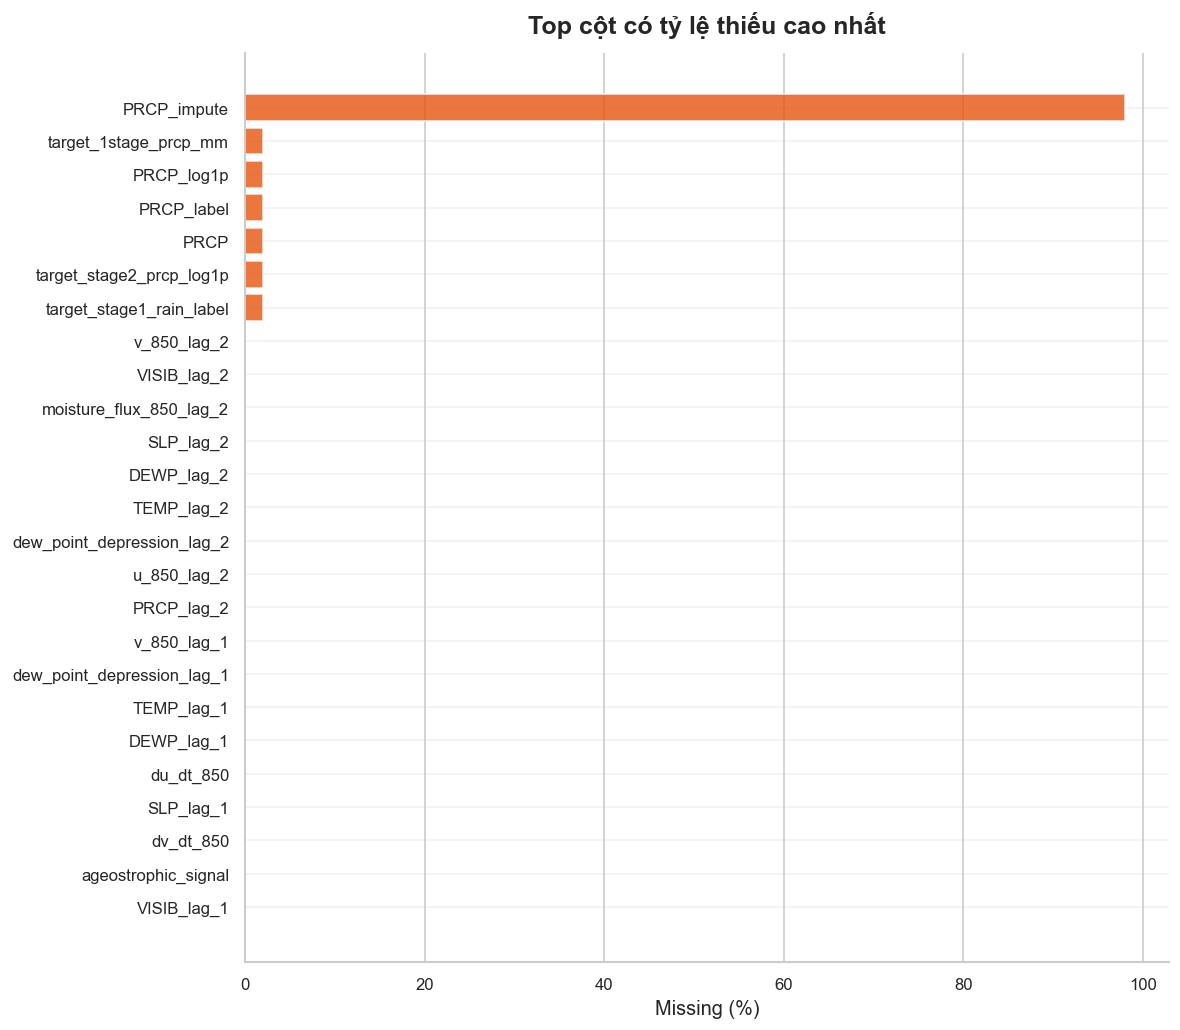

In [25]:
# =============================================================================
# 1.2. Missingness analysis
# =============================================================================

missing_summary = pd.DataFrame(
    {
        "column": df_raw.columns,
        "missing_count": [int(df_raw[col].isna().sum()) for col in df_raw.columns],
        "missing_percent": [float(df_raw[col].isna().mean() * 100) for col in df_raw.columns],
        "dtype": [str(df_raw[col].dtype) for col in df_raw.columns],
    }
).sort_values("missing_percent", ascending=False)

display(missing_summary.head(30))

top_missing = missing_summary[missing_summary["missing_count"] > 0].head(25)

if not top_missing.empty:
    plt.figure(figsize=(10, max(4, 0.35 * len(top_missing))))
    y = np.arange(len(top_missing))
    plt.barh(y, top_missing["missing_percent"], color=ORANGE_COLOR, alpha=0.8)
    plt.yticks(y, top_missing["column"])
    plt.gca().invert_yaxis()
    ax = clean_axis(plt.gca(), "Top cột có tỷ lệ thiếu cao nhất", "Missing (%)", "")
    plt.tight_layout()
    plt.show()
else:
    print("Không có cột nào bị thiếu.")

In [26]:
# Missing PRCP theo trạm

prcp_missing_by_station = (
    df_raw.groupby(["STATION", "station_name"], dropna=False)
    .agg(
        n_rows=("PRCP", "size"),
        prcp_missing=("PRCP", lambda s: int(s.isna().sum())),
        prcp_non_missing=("PRCP", lambda s: int(s.notna().sum())),
        rain_days=("PRCP_label", lambda s: int((s == 1).sum())),
        non_rain_days=("PRCP_label", lambda s: int((s == 0).sum())),
        mean_prcp_mm=("PRCP", "mean"),
        median_prcp_mm=("PRCP", "median"),
        max_prcp_mm=("PRCP", "max"),
    )
    .reset_index()
)

prcp_missing_by_station["prcp_missing_percent"] = (
    prcp_missing_by_station["prcp_missing"] / prcp_missing_by_station["n_rows"] * 100
)
prcp_missing_by_station["rain_rate_percent"] = (
    prcp_missing_by_station["rain_days"] / prcp_missing_by_station["prcp_non_missing"].replace(0, np.nan) * 100
)

display(prcp_missing_by_station)

,STATION,station_name,n_rows,prcp_missing,prcp_non_missing,rain_days,non_rain_days,mean_prcp_mm,median_prcp_mm,max_prcp_mm,prcp_missing_percent,rain_rate_percent
0,48825099999,Ha Dong,3653,92,3561,1351,2210,4.943264,0.0,337.820,2.518478,37.938781
1,48845099999,Vinh,3653,93,3560,1321,2239,6.462160,0.0,363.220,2.545853,37.106742
2,48863099999,Quang Ngai,3653,58,3595,1430,2165,7.235149,0.0,369.062,1.587736,39.777469
3,48877099999,Nha Trang,3653,77,3576,1117,2459,4.144476,0.0,381.254,2.107857,31.236018
4,48914099999,Ca Mau,3653,49,3604,1592,2012,6.323289,0.0,186.944,1.341363,44.173141


In [27]:
# Missing PRCP theo năm/tháng

prcp_missing_by_year_month = (
    df_raw.groupby(["year", "month"], dropna=False)
    .agg(
        n_rows=("PRCP", "size"),
        prcp_missing=("PRCP", lambda s: int(s.isna().sum())),
        prcp_non_missing=("PRCP", lambda s: int(s.notna().sum())),
        rain_days=("PRCP_label", lambda s: int((s == 1).sum())),
        total_prcp_mm=("PRCP", "sum"),
        mean_prcp_mm=("PRCP", "mean"),
    )
    .reset_index()
)

prcp_missing_by_year_month["prcp_missing_percent"] = (
    prcp_missing_by_year_month["prcp_missing"] / prcp_missing_by_year_month["n_rows"] * 100
)
prcp_missing_by_year_month["rain_rate_percent"] = (
    prcp_missing_by_year_month["rain_days"] / prcp_missing_by_year_month["prcp_non_missing"].replace(0, np.nan) * 100
)

display(prcp_missing_by_year_month.head(15))

,year,month,n_rows,prcp_missing,prcp_non_missing,rain_days,total_prcp_mm,mean_prcp_mm,prcp_missing_percent,rain_rate_percent
0,2015,1,155,6,149,33,266.954,1.791638,3.870968,22.147651
1,2015,2,140,4,136,34,151.892,1.116853,2.857143,25.000000
2,2015,3,155,0,155,45,251.206,1.620684,0.000000,29.032258
3,2015,4,150,2,148,31,182.880,1.235676,1.333333,20.945946
4,2015,5,155,1,154,31,482.600,3.133766,0.645161,20.129870
5,2015,6,150,2,148,51,845.312,5.711568,1.333333,34.459459
6,2015,7,155,3,152,68,605.282,3.982118,1.935484,44.736842
7,2015,8,155,0,155,57,668.020,4.309806,0.000000,36.774194
8,2015,9,150,0,150,66,1565.656,10.437707,0.000000,44.000000
9,2015,10,155,1,154,64,1005.332,6.528130,0.645161,41.558442


## 2. Phân phối lượng mưa

Mục tiêu:

- Chứng minh `PRCP` có nhiều giá trị 0.
- Chứng minh phân phối bị lệch phải mạnh.
- Tạo cơ sở cho mô hình Tweedie và Two-stage ở bước model validation.

,subset,quantile,prcp_mm
0,all_non_missing_prcp,0.00,0.0000
1,all_non_missing_prcp,0.01,0.0000
2,all_non_missing_prcp,0.05,0.0000
3,all_non_missing_prcp,0.25,0.0000
4,all_non_missing_prcp,0.50,0.0000
5,all_non_missing_prcp,0.75,2.2860
6,all_non_missing_prcp,0.90,16.0020
7,all_non_missing_prcp,0.95,32.2580
8,all_non_missing_prcp,0.99,86.6140
9,all_non_missing_prcp,1.00,381.2540


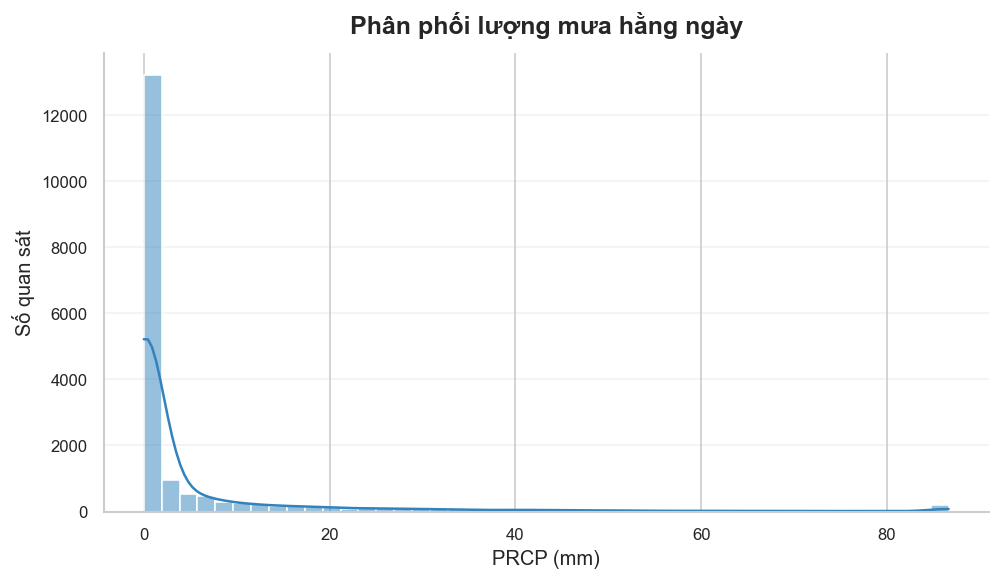

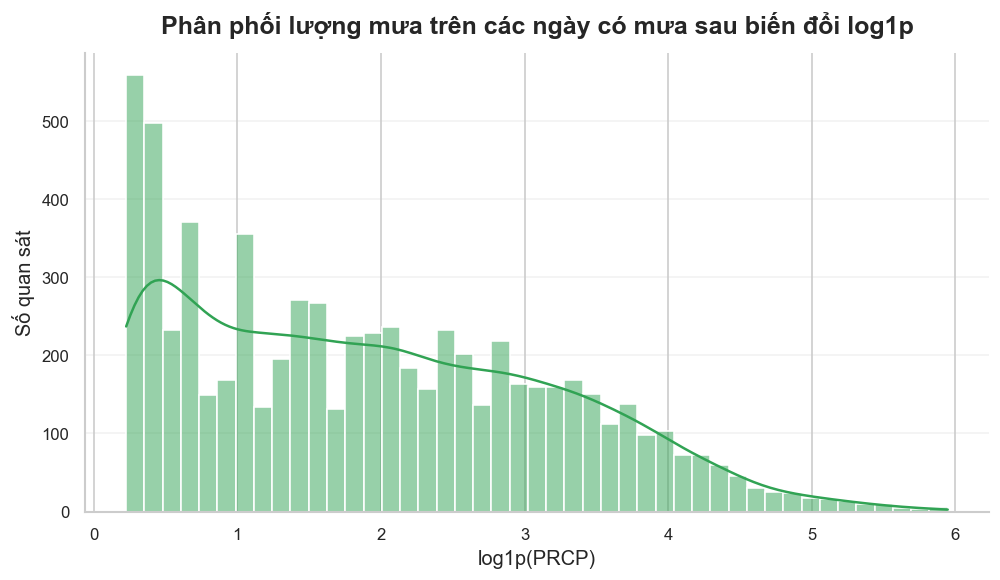

In [28]:
# =============================================================================
# 2. Phân phối lượng mưa
# =============================================================================

quantiles = [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
quantile_rows = []

for subset_name, series in [
    ("all_non_missing_prcp", df["PRCP"].dropna()),
    ("rainy_days_only", df.loc[df["PRCP_label"].eq(1), "PRCP"].dropna()),
]:
    q = series.quantile(quantiles)
    for prob, value in q.items():
        quantile_rows.append({"subset": subset_name, "quantile": prob, "prcp_mm": float(value)})

prcp_quantiles = pd.DataFrame(quantile_rows)
display(prcp_quantiles)

# Biểu đồ 1: phân phối PRCP, clip ở P99 để dễ nhìn
cap = df["PRCP"].quantile(0.99)

plt.figure(figsize=(8.5, 5))
sns.histplot(df["PRCP"].clip(upper=cap), bins=45, kde=True, color=RAIN_COLOR)
clean_axis(
    plt.gca(),
    f"Phân phối lượng mưa hằng ngày",
    "PRCP (mm)",
    "Số quan sát",
)
plt.tight_layout()
plt.show()

# Biểu đồ 2: log1p(PRCP) trên ngày mưa
plt.figure(figsize=(8.5, 5))
sns.histplot(df.loc[df["PRCP_label"].eq(1), "PRCP_log1p"], bins=45, kde=True, color=ACCENT_COLOR)
clean_axis(
    plt.gca(),
    "Phân phối lượng mưa trên các ngày có mưa sau biến đổi log1p",
    "log1p(PRCP)",
    "Số quan sát",
)
plt.tight_layout()
plt.show()

## 3. Tỷ lệ mưa

Mục tiêu:

- Tính tỉ lệ ngày mưa và không mưa.
- Chứng minh dữ liệu có tính zero-inflated.

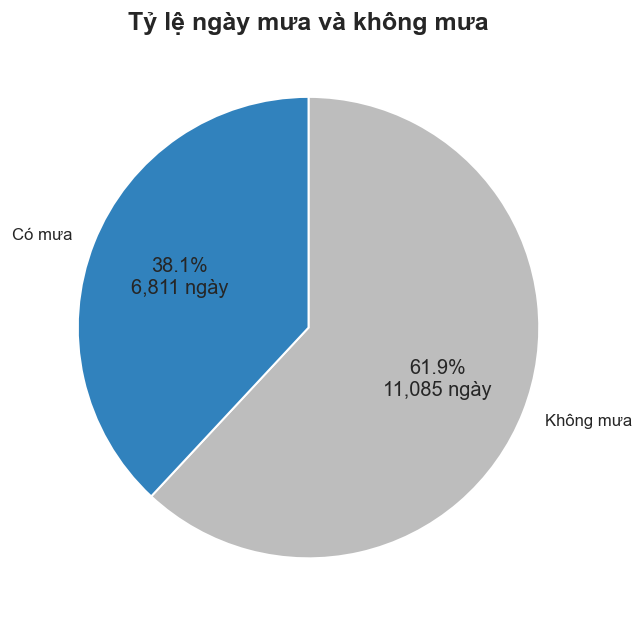

,rain_status,count,percent
0,Không mưa,11085,61.941216
1,Có mưa,6811,38.058784


In [29]:
# =============================================================================
# 3. Tỷ lệ ngày mưa / không mưa
# =============================================================================

rain_counts = (
    df["rain_status"]
    .value_counts()
    .reindex(["Không mưa", "Có mưa"])
    .fillna(0)
)

rain_total = rain_counts.sum()

def show_pct_count(pct, total):
    count = int(round(pct * total / 100))
    return f"{pct:.1f}%\n{count:,} ngày"

plt.figure(figsize=(5.8, 5.4))
plt.pie(
    rain_counts.values,
    labels=rain_counts.index,
    colors=[DRY_COLOR, RAIN_COLOR],
    autopct=lambda pct: show_pct_count(pct, rain_total),
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
plt.title("Tỷ lệ ngày mưa và không mưa", fontweight="bold")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "rain_status": rain_counts.index,
        "count": rain_counts.values.astype(int),
        "percent": rain_counts.values / rain_total * 100,
    })
)

**Kết luận ngắn:**  
Vì số ngày không mưa chiếm tỉ lệ lớn, `median PRCP` bằng 0.0 mm là hợp lý và là bằng chứng trực tiếp cho đặc điểm zero-inflated của dữ liệu mưa.

## 4. Mùa vụ theo tháng

Mục tiêu:

- Phân tích xác suất mưa theo tháng.
- Phân tích lượng mưa trung bình theo tháng.
- Biện luận cho các feature chu kỳ như `month_sin`, `month_cos`, `day_sin`, `day_cos`.

,month,rain_prob,rain_days,n_days,total_prcp,mean_prcp,median_prcp,p95_prcp,max_prcp,month_name
0,1,0.326274,493.0,1511,3305.556,2.187661,0.000,11.1760,131.064,Jan
1,2,0.246220,342.0,1389,1591.818,1.146017,0.000,5.3340,68.326,Feb
2,3,0.210317,318.0,1512,1937.258,1.281255,0.000,4.5720,218.440,Mar
3,4,0.229096,337.0,1471,3218.688,2.188095,0.000,12.1920,124.460,Apr
4,5,0.345526,529.0,1531,6694.170,4.372417,0.000,26.0350,337.820,May
5,6,0.345013,512.0,1484,6668.262,4.493438,0.000,26.9240,239.522,Jun
6,7,0.419103,645.0,1539,10176.256,6.612252,0.000,35.6108,189.484,Jul
7,8,0.433987,664.0,1530,10027.920,6.554196,0.000,40.1574,153.924,Aug
8,9,0.515379,754.0,1463,16774.668,11.465938,0.254,60.4266,369.062,Sep
9,10,0.567909,853.0,1502,19802.856,13.184325,0.762,61.4680,363.220,Oct


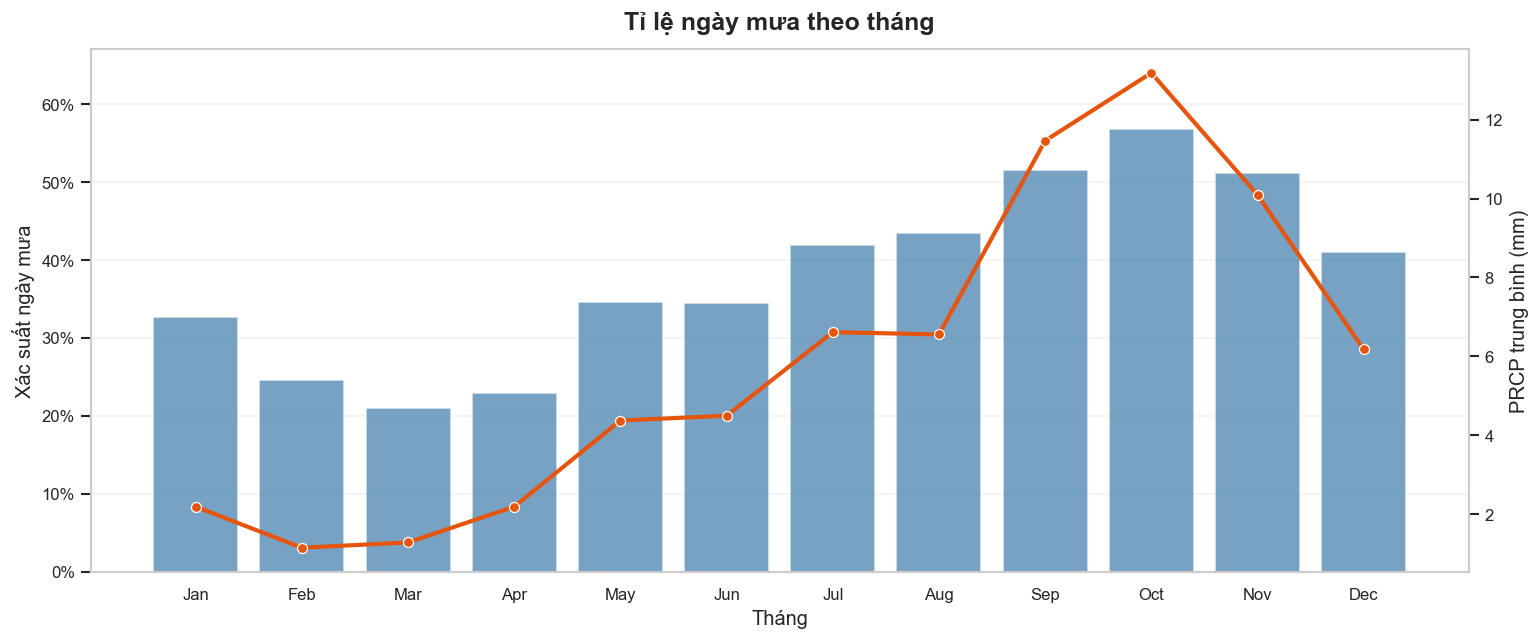

In [30]:
# =============================================================================
# 4. Mùa vụ theo tháng
# =============================================================================

monthly = (
    df.groupby("month", as_index=False)
    .agg(
        rain_prob=("PRCP_label", "mean"),
        rain_days=("PRCP_label", "sum"),
        n_days=("PRCP_label", "count"),
        total_prcp=("PRCP", "sum"),
        mean_prcp=("PRCP", "mean"),
        median_prcp=("PRCP", "median"),
        p95_prcp=("PRCP", lambda s: float(s.quantile(0.95))),
        max_prcp=("PRCP", "max"),
    )
)

monthly["month_name"] = pd.Categorical(
    monthly["month"].map(lambda m: MONTH_LABELS[int(m) - 1]),
    MONTH_LABELS,
    ordered=True,
)

display(monthly)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax2 = ax1.twinx()

sns.barplot(data=monthly, x="month_name", y="rain_prob", color=RAIN_COLOR, alpha=0.72, ax=ax1)
sns.lineplot(data=monthly, x="month_name", y="mean_prcp", color=ORANGE_COLOR, marker="o", linewidth=2.5, ax=ax2)

ax1.set_ylabel("Xác suất ngày mưa")
ax2.set_ylabel("PRCP trung bình (mm)")
ax1.set_xlabel("Tháng")
ax1.set_ylim(0, max(0.05, monthly["rain_prob"].max() * 1.18))
ax1.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

clean_axis(ax1, "Tỉ lệ ngày mưa theo tháng", "Tháng", "Xác suất ngày mưa")
ax2.grid(False)
plt.tight_layout()
plt.show()

## 5. Heatmap mùa vụ và phân phối mưa theo trạm

Mục tiêu:

- Phân tích tương tác giữa trạm và mùa vụ.
- Kiểm tra sự khác biệt phân phối lượng mưa giữa các trạm.

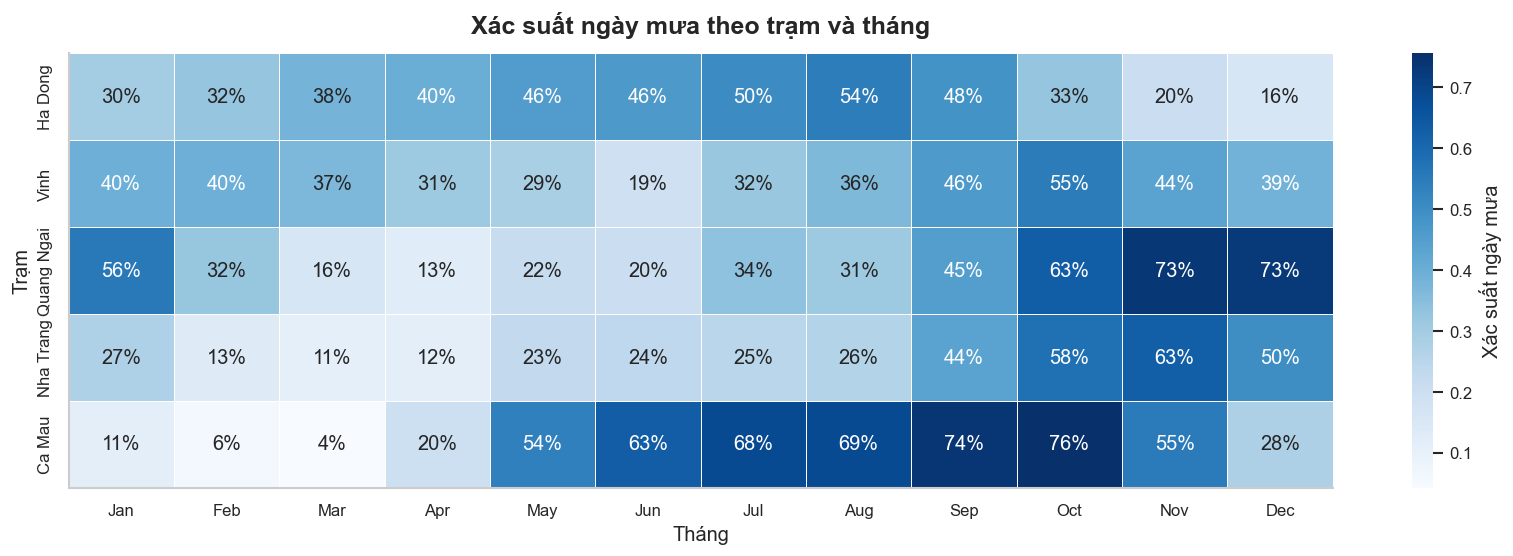

In [31]:
# =============================================================================
# 5. Heatmap mùa vụ theo trạm
# =============================================================================

station_month = (
    df.pivot_table(
        index="station_name",
        columns="month_name",
        values="PRCP_label",
        aggfunc="mean",
        observed=False,
    )
    .reindex(station_order)
)

plt.figure(figsize=(14, 4.8))
ax = sns.heatmap(
    station_month,
    cmap="Blues",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    cbar_kws={"label": "Xác suất ngày mưa"},
)
clean_axis(ax, "Xác suất ngày mưa theo trạm và tháng", "Tháng", "Trạm")
plt.tight_layout()
plt.show()

,STATION,station_name,n_rows,rain_days,total_prcp_mm,mean_prcp_mm,median_prcp_mm,p95_prcp_mm,p99_prcp_mm,max_prcp_mm,rain_rate_percent
0,48825099999,Ha Dong,3561,1351.0,17602.962,4.943264,0.0,31.4960,75.84440,337.820,37.938781
1,48845099999,Vinh,3560,1321.0,23005.288,6.462160,0.0,35.8140,116.39042,363.220,37.106742
2,48863099999,Quang Ngai,3595,1430.0,26010.362,7.235149,0.0,37.9222,134.12724,369.062,39.777469
3,48877099999,Nha Trang,3576,1117.0,14820.646,4.144476,0.0,22.9235,73.15200,381.254,31.236018
4,48914099999,Ca Mau,3604,1592.0,22789.134,6.323289,0.0,33.0200,65.02400,186.944,44.173141


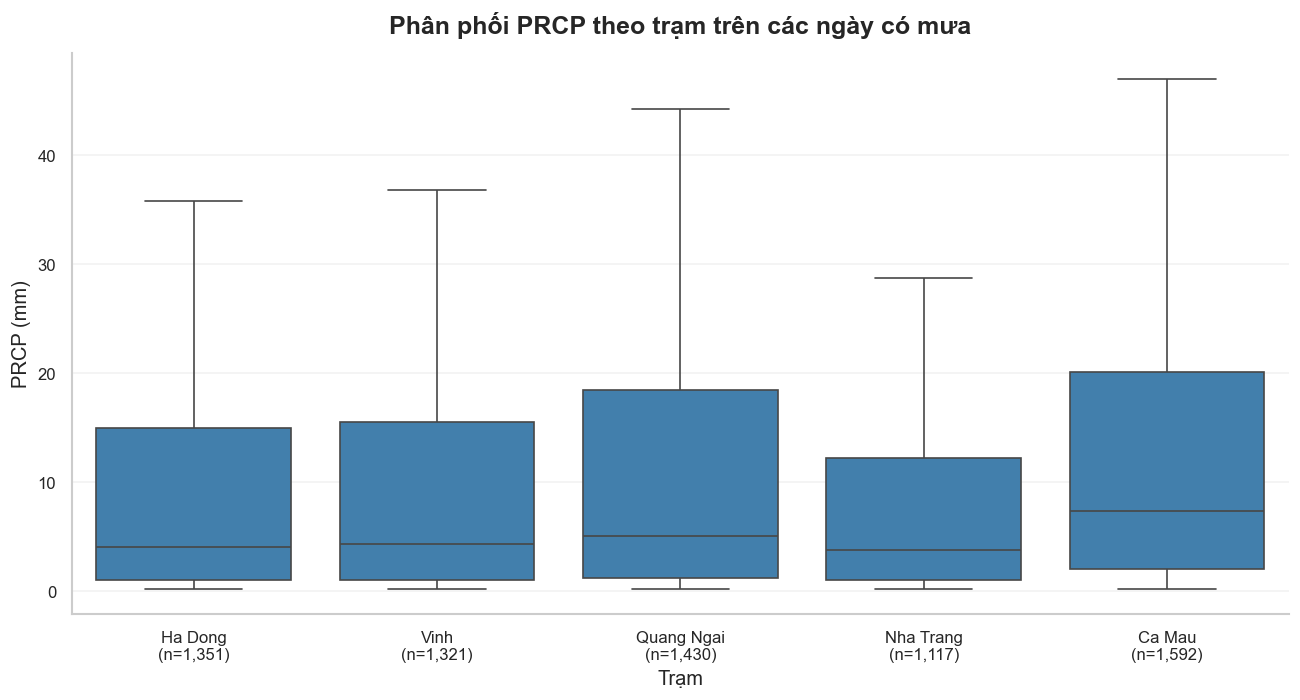

In [32]:
# =============================================================================
# 5.1. Phân phối lượng mưa theo trạm
# =============================================================================

station_summary = (
    df.groupby(["STATION", "station_name"], as_index=False)
    .agg(
        n_rows=("PRCP", "size"),
        rain_days=("PRCP_label", "sum"),
        total_prcp_mm=("PRCP", "sum"),
        mean_prcp_mm=("PRCP", "mean"),
        median_prcp_mm=("PRCP", "median"),
        p95_prcp_mm=("PRCP", lambda s: float(s.quantile(0.95))),
        p99_prcp_mm=("PRCP", lambda s: float(s.quantile(0.99))),
        max_prcp_mm=("PRCP", "max"),
    )
)

station_summary["rain_rate_percent"] = station_summary["rain_days"] / station_summary["n_rows"] * 100
display(station_summary)

rainy_days = df[df["PRCP_label"].eq(1)].copy()

station_labels = (
    rainy_days["station_name"]
    .value_counts()
    .reindex(station_order)
    .dropna()
)

station_order_rainy = station_labels.index.tolist()
xtick_labels = [f"{station}\n(n={int(station_labels[station]):,})" for station in station_order_rainy]

plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=rainy_days,
    x="station_name",
    y="PRCP",
    order=station_order_rainy,
    color=RAIN_COLOR,
    showfliers=False,
)
ax.set_xticklabels(xtick_labels)
clean_axis(ax, "Phân phối PRCP theo trạm trên các ngày có mưa", "Trạm", "PRCP (mm)")
plt.tight_layout()
plt.show()

**Kết luận ngắn:**  
Mưa thay đổi theo cả thời gian và không gian. Vì vậy, việc giữ các feature thời gian và vị trí như `LATITUDE`, `LONGITUDE`, `ELEVATION` là hợp lý.

## 5.2. Phân tích theo năm và kiểm tra train/valid/test

Mục tiêu:

- Kiểm tra phân phối mưa theo năm.
- Kiểm tra split theo thời gian.
- Đảm bảo EDA không khuyến khích random split.

,year,n_rows,prcp_non_missing,prcp_missing,rain_days,total_prcp_mm,mean_prcp_mm,median_prcp_mm,p95_prcp_mm,max_prcp_mm,rain_rate_percent,prcp_missing_percent
0,2015,1825,1803,22,637,9056.878,5.023227,0.0,29.7180,202.438,35.330006,1.205479
1,2016,1830,1803,27,679,11595.862,6.431427,0.0,33.0200,339.598,37.659456,1.475410
2,2017,1825,1780,45,774,10591.546,5.950307,0.0,31.4960,314.960,43.483146,2.465753
3,2018,1825,1799,26,675,9851.136,5.475895,0.0,30.2514,381.254,37.520845,1.424658
4,2019,1825,1814,11,647,8693.150,4.792255,0.0,26.9240,310.896,35.667034,0.602740
5,2020,1830,1816,14,644,10805.160,5.949978,0.0,34.6075,363.220,35.462555,0.765027
6,2021,1825,1783,42,649,12022.582,6.742895,0.0,36.7284,369.062,36.399327,2.301370
7,2022,1825,1763,62,724,11482.578,6.513090,0.0,38.1000,236.474,41.066364,3.397260
8,2023,1825,1794,31,715,9805.416,5.465672,0.0,28.9560,210.058,39.855072,1.698630
9,2024,1830,1741,89,667,10324.084,5.929974,0.0,34.0360,295.402,38.311315,4.863388


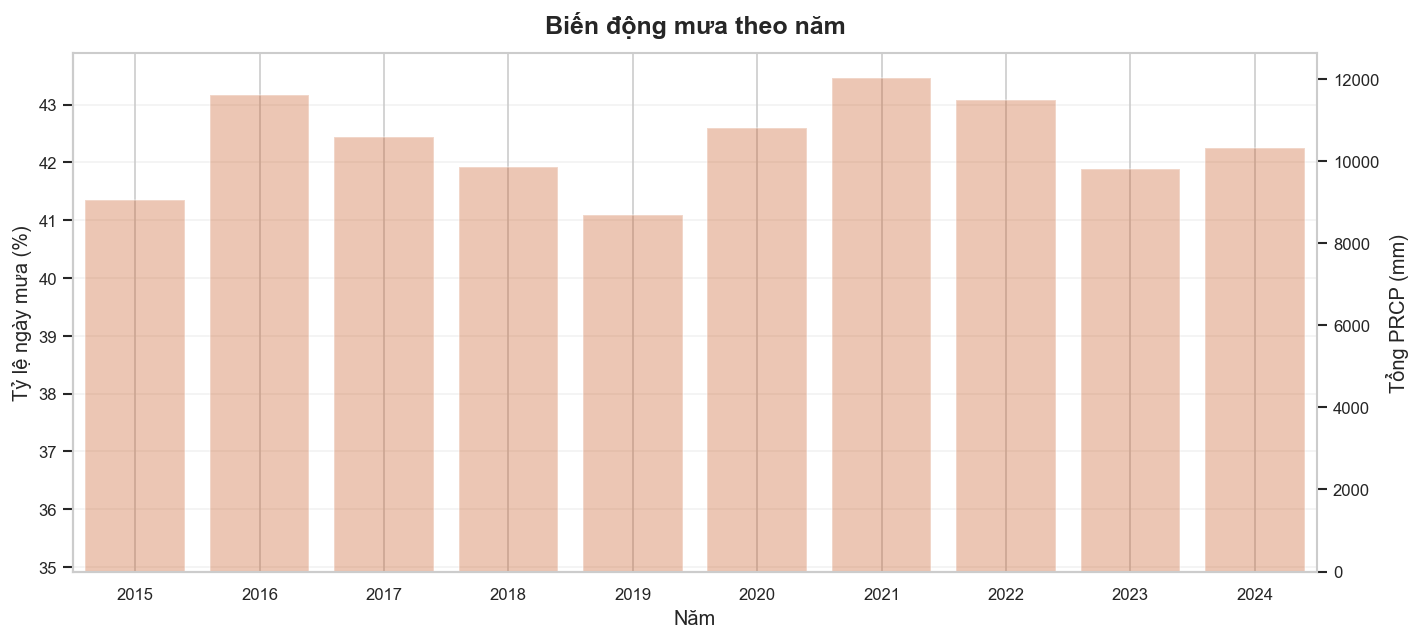

In [33]:
# =============================================================================
# 5.2. Yearly analysis
# =============================================================================

yearly_summary = (
    df_raw.groupby("year")
    .agg(
        n_rows=("PRCP", "size"),
        prcp_non_missing=("PRCP", lambda s: int(s.notna().sum())),
        prcp_missing=("PRCP", lambda s: int(s.isna().sum())),
        rain_days=("PRCP_label", lambda s: int((s == 1).sum())),
        total_prcp_mm=("PRCP", "sum"),
        mean_prcp_mm=("PRCP", "mean"),
        median_prcp_mm=("PRCP", "median"),
        p95_prcp_mm=("PRCP", lambda s: float(s.dropna().quantile(0.95)) if s.notna().any() else np.nan),
        max_prcp_mm=("PRCP", "max"),
    )
    .reset_index()
)

yearly_summary["rain_rate_percent"] = yearly_summary["rain_days"] / yearly_summary["prcp_non_missing"].replace(0, np.nan) * 100
yearly_summary["prcp_missing_percent"] = yearly_summary["prcp_missing"] / yearly_summary["n_rows"] * 100

display(yearly_summary)

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()

sns.lineplot(data=yearly_summary, x="year", y="rain_rate_percent", marker="o", linewidth=2.5, color=RAIN_COLOR, ax=ax1)
sns.barplot(data=yearly_summary, x="year", y="total_prcp_mm", alpha=0.35, color=ORANGE_COLOR, ax=ax2)

ax1.set_ylabel("Tỷ lệ ngày mưa (%)")
ax2.set_ylabel("Tổng PRCP (mm)")
ax1.set_xlabel("Năm")
clean_axis(ax1, "Biến động mưa theo năm", "Năm", "Tỷ lệ ngày mưa (%)")
ax2.grid(False)
plt.tight_layout()
plt.show()

,split,n_rows,time_min,time_max,prcp_non_missing,prcp_missing,rain_days,non_rain_days,total_prcp_mm,mean_prcp_mm,median_prcp_mm,p95_prcp_mm,max_prcp_mm,rain_rate_percent,prcp_missing_percent
1,Train 2015-2022,14610,2015-01-01,2022-12-31,14361,249,5429,8932,84098.892,5.856061,0.0,32.512,381.254,37.803774,1.704312
2,Validation 2023,1825,2023-01-01,2023-12-31,1794,31,715,1079,9805.416,5.465672,0.0,28.956,210.058,39.855072,1.698630
0,Test 2024,1830,2024-01-01,2024-12-31,1741,89,667,1074,10324.084,5.929974,0.0,34.036,295.402,38.311315,4.863388


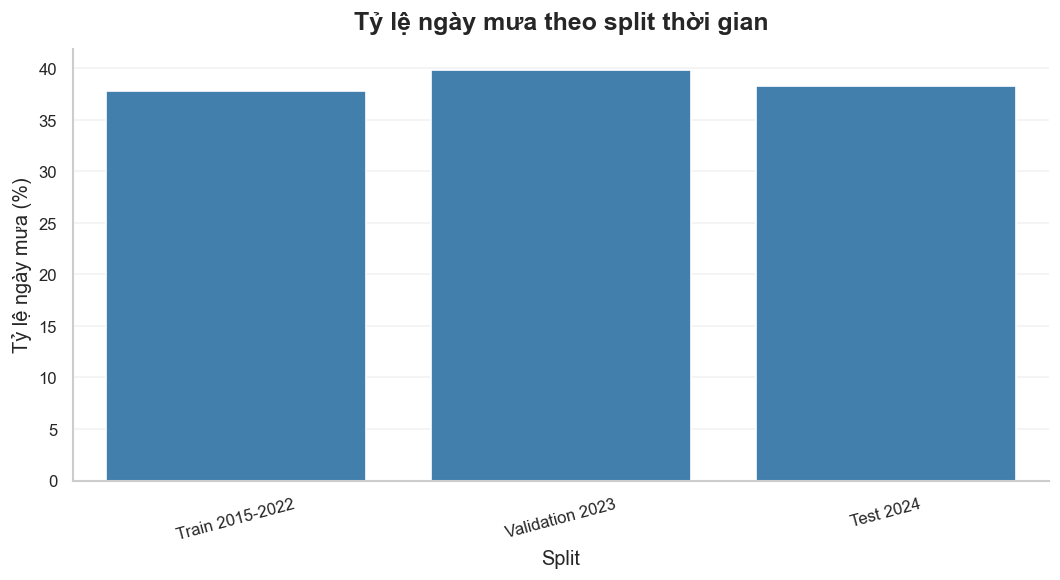

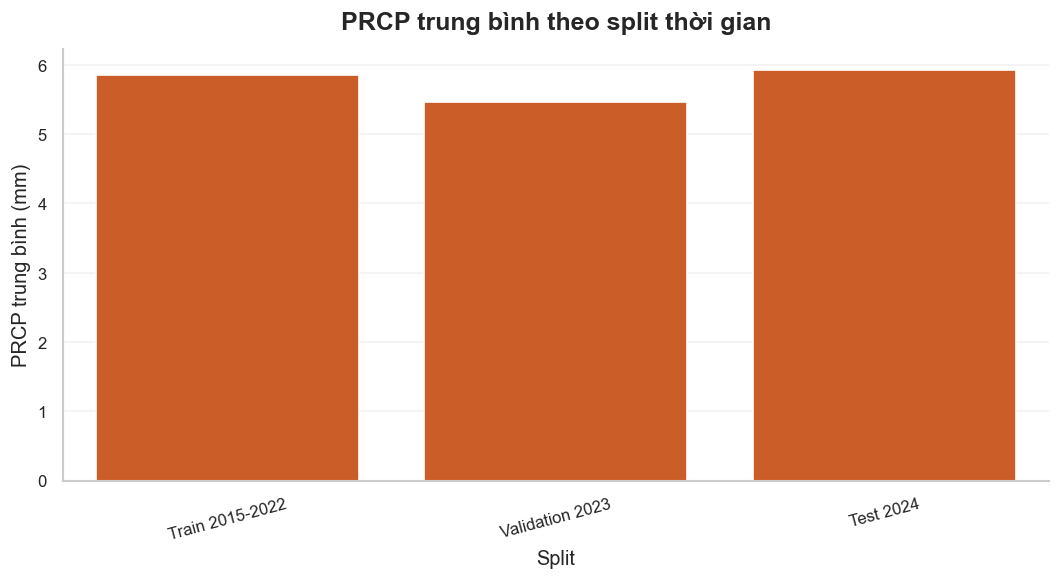

In [34]:
# =============================================================================
# 5.3. Time split sanity check
# =============================================================================

split_order = ["Train 2015-2022", "Validation 2023", "Test 2024"]

split_summary = (
    df_raw.groupby("split")
    .agg(
        n_rows=("PRCP", "size"),
        time_min=("time", "min"),
        time_max=("time", "max"),
        prcp_non_missing=("PRCP", lambda s: int(s.notna().sum())),
        prcp_missing=("PRCP", lambda s: int(s.isna().sum())),
        rain_days=("PRCP_label", lambda s: int((s == 1).sum())),
        non_rain_days=("PRCP_label", lambda s: int((s == 0).sum())),
        total_prcp_mm=("PRCP", "sum"),
        mean_prcp_mm=("PRCP", "mean"),
        median_prcp_mm=("PRCP", "median"),
        p95_prcp_mm=("PRCP", lambda s: float(s.dropna().quantile(0.95)) if s.notna().any() else np.nan),
        max_prcp_mm=("PRCP", "max"),
    )
    .reset_index()
)

split_summary["split"] = pd.Categorical(split_summary["split"], split_order, ordered=True)
split_summary = split_summary.sort_values("split")
split_summary["rain_rate_percent"] = split_summary["rain_days"] / split_summary["prcp_non_missing"].replace(0, np.nan) * 100
split_summary["prcp_missing_percent"] = split_summary["prcp_missing"] / split_summary["n_rows"] * 100

display(split_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=split_summary, x="split", y="rain_rate_percent", color=RAIN_COLOR)
clean_axis(ax, "Tỷ lệ ngày mưa theo split thời gian", "Split", "Tỷ lệ ngày mưa (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=split_summary, x="split", y="mean_prcp_mm", color=ORANGE_COLOR)
clean_axis(ax, "PRCP trung bình theo split thời gian", "Split", "PRCP trung bình (mm)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Kết luận ngắn:**  
Dữ liệu được chia theo thời gian nên không có hiện tượng dùng tương lai để dự báo quá khứ. Đây là cách đánh giá phù hợp với dữ liệu khí tượng dạng thời gian.

## 6. Tương quan giữa các feature quan trọng

Mục tiêu:

- Khám phá mối quan hệ giữa các feature.
- Nhận diện nhóm biến có tương quan cao.
- Đây chỉ là EDA, **không thực hiện feature selection cuối cùng**.

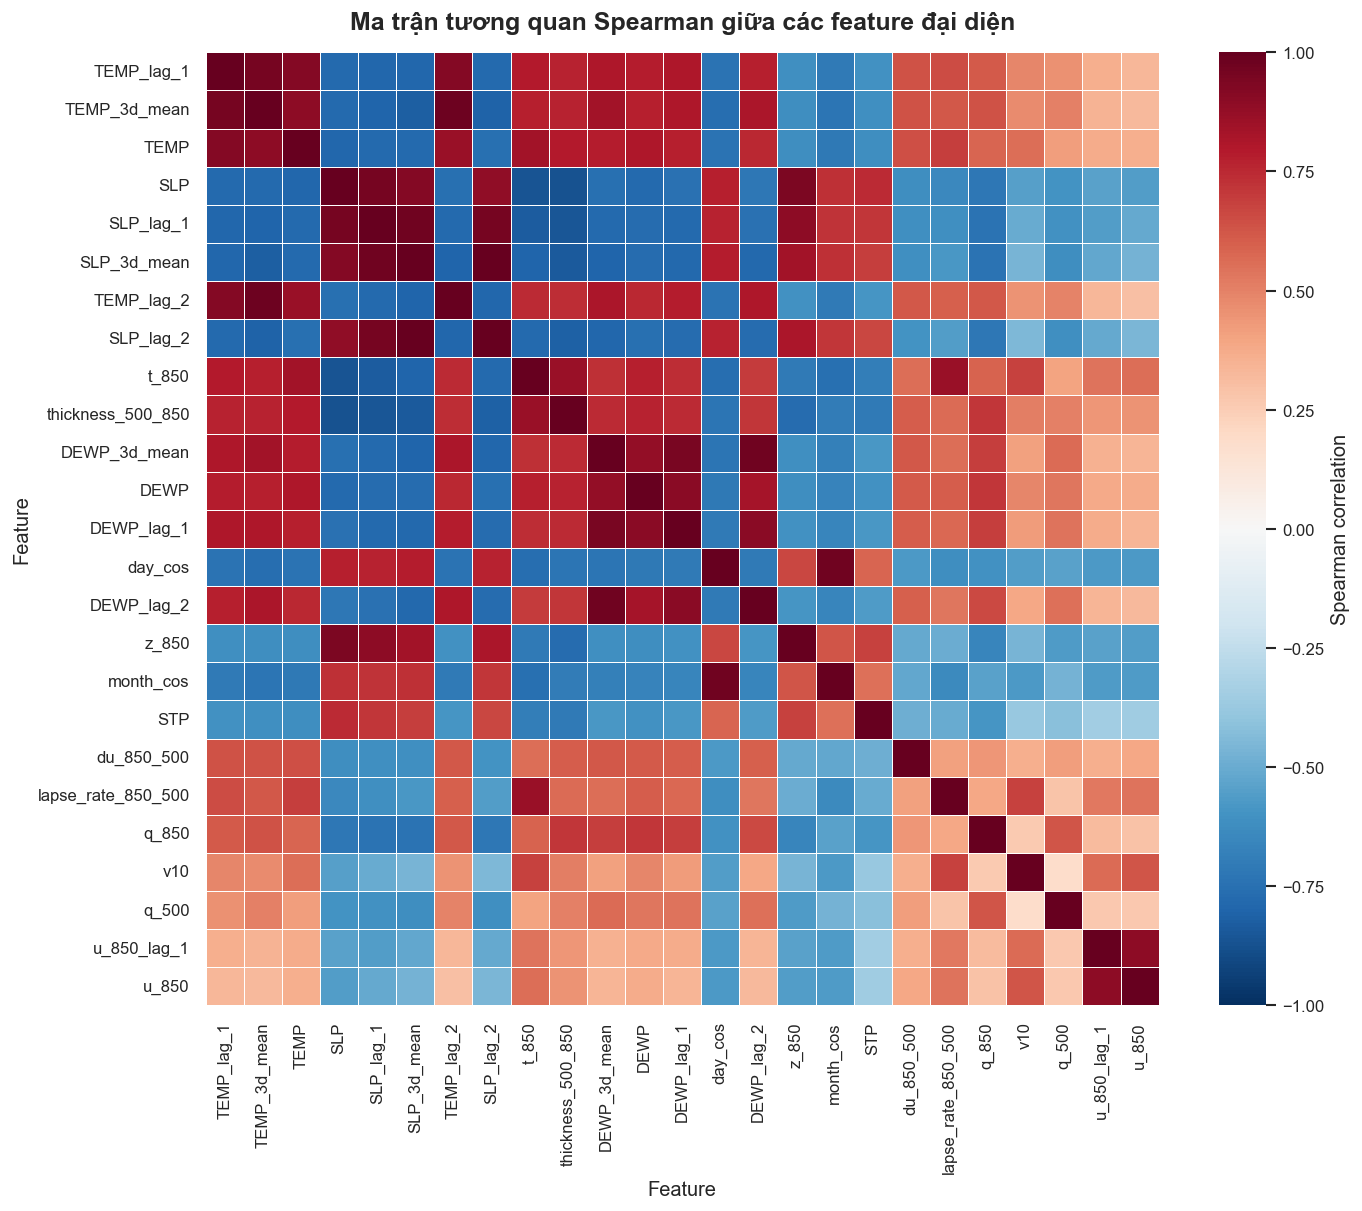

In [35]:
# =============================================================================
# 6. Feature correlation EDA
# =============================================================================

# Chỉ phân tích trên train set để tránh nhìn vào validation/test
numeric_features = [
    col for col in feature_cols
    if col in train_df.columns
    and pd.api.types.is_numeric_dtype(train_df[col])
    and train_df[col].nunique(dropna=True) > 1
]

if len(numeric_features) < 2:
    print("Không đủ feature numeric hợp lệ để tính correlation.")
else:
    # Spearman phù hợp hơn Pearson vì dữ liệu mưa lệch phải và có quan hệ phi tuyến/đơn điệu
    feature_corr = train_df[numeric_features].corr(method="spearman", numeric_only=True)

    # Chọn các feature đại diện có mức tương quan trung bình cao với các feature khác
    # Loại đường chéo chính để tránh giá trị self-correlation = 1 làm sai ranking
    corr_no_diag = feature_corr.abs().copy()
    np.fill_diagonal(corr_no_diag.values, np.nan)

    top_corr_features = (
        corr_no_diag
        .mean(skipna=True)
        .sort_values(ascending=False)
        .head(25)
        .index
    )

    corr_plot = feature_corr.loc[top_corr_features, top_corr_features]

    plt.figure(figsize=(12, 10))

    ax = sns.heatmap(
        corr_plot,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"label": "Spearman correlation"},
    )

    ax.set_title(
        "Ma trận tương quan Spearman giữa các feature đại diện",
        pad=14,
        fontweight="bold",
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 7. Tương quan feature-target trên train set

Mục tiêu:

- Xem quan hệ đơn biến giữa feature và `PRCP`.
- Chỉ dùng train set để tránh nhìn vào test khi phân tích tương quan.
- Đây là EDA giải thích dữ liệu, **không phải chọn lọc đặc trưng cuối cùng**.

,feature,spearman
0,dew_point_depression,-0.551266
1,PRCP_lag_1,0.453910
2,PRCP_past_3d_mean,0.411990
3,PRCP_past_3d_sum,0.411990
4,VISIB,-0.398893
5,dew_point_depression_lag_1,-0.393112
6,q_500,0.356612
7,VISIB_lag_1,-0.350434
8,dew_point_depression_3d_mean,-0.321165
9,moisture_flux_850,0.297514


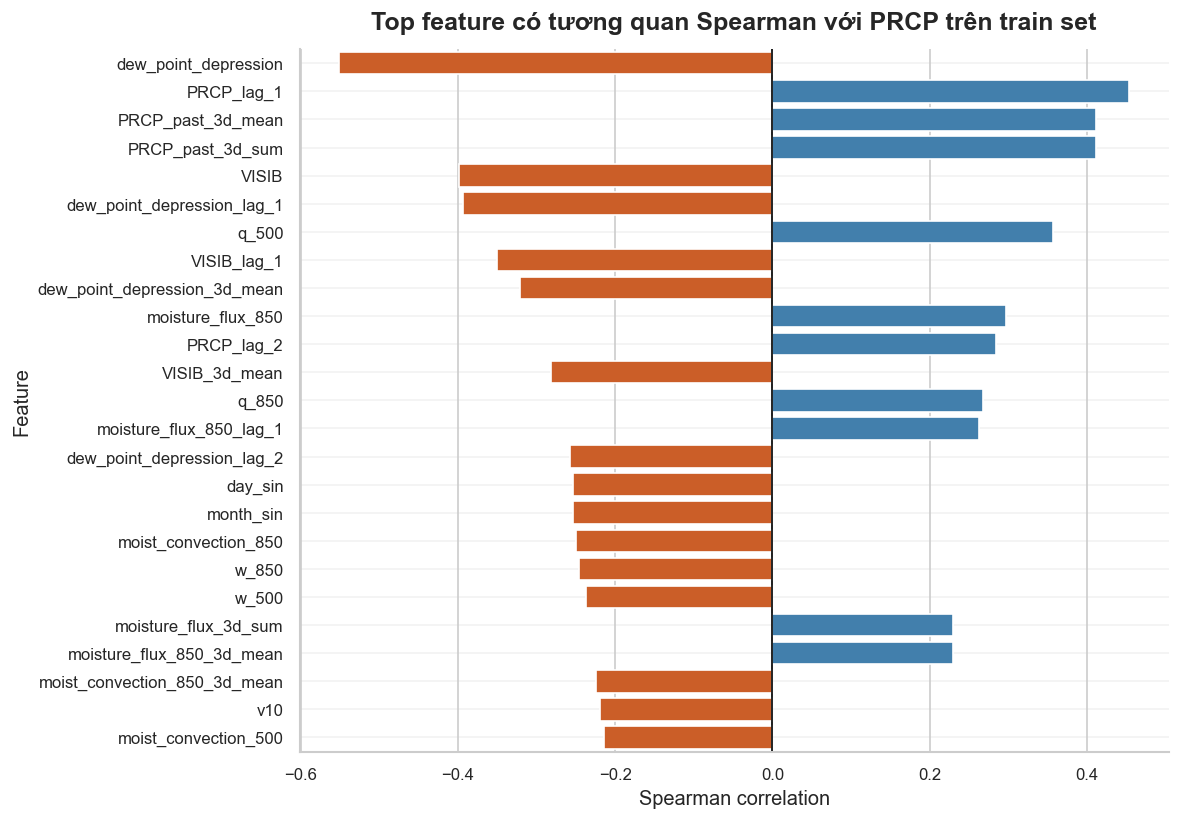

In [36]:
# =============================================================================
# 7. Feature-target correlation on train set
# =============================================================================

if not feature_cols:
    print("Không có feature numeric để phân tích.")
else:
    target_corr = (
        train_df[feature_cols + ["PRCP"]]
        .corr(method="spearman", numeric_only=True)["PRCP"]
        .drop("PRCP")
        .dropna()
    )

    corr_df = (
        target_corr
        .reindex(target_corr.abs().sort_values(ascending=False).head(25).index)
        .reset_index()
    )

    corr_df.columns = ["feature", "spearman"]
    display(corr_df)

    plt.figure(figsize=(10, 7))
    ax = sns.barplot(
        data=corr_df,
        x="spearman",
        y="feature",
        hue=corr_df["spearman"] > 0,
        dodge=False,
        palette={True: RAIN_COLOR, False: ORANGE_COLOR},
        legend=False,
    )
    ax.axvline(0, color="black", linewidth=1)
    clean_axis(ax, "Top feature có tương quan Spearman với PRCP trên train set", "Spearman correlation", "Feature")
    plt.tight_layout()
    plt.show()

## 8. So sánh feature khí tượng giữa ngày mưa và không mưa

Mục tiêu:

- Kiểm tra một số feature khí tượng có khác nhau giữa ngày mưa và không mưa hay không.
- Tạo insight để giải thích vì sao các feature khí tượng có ý nghĩa.

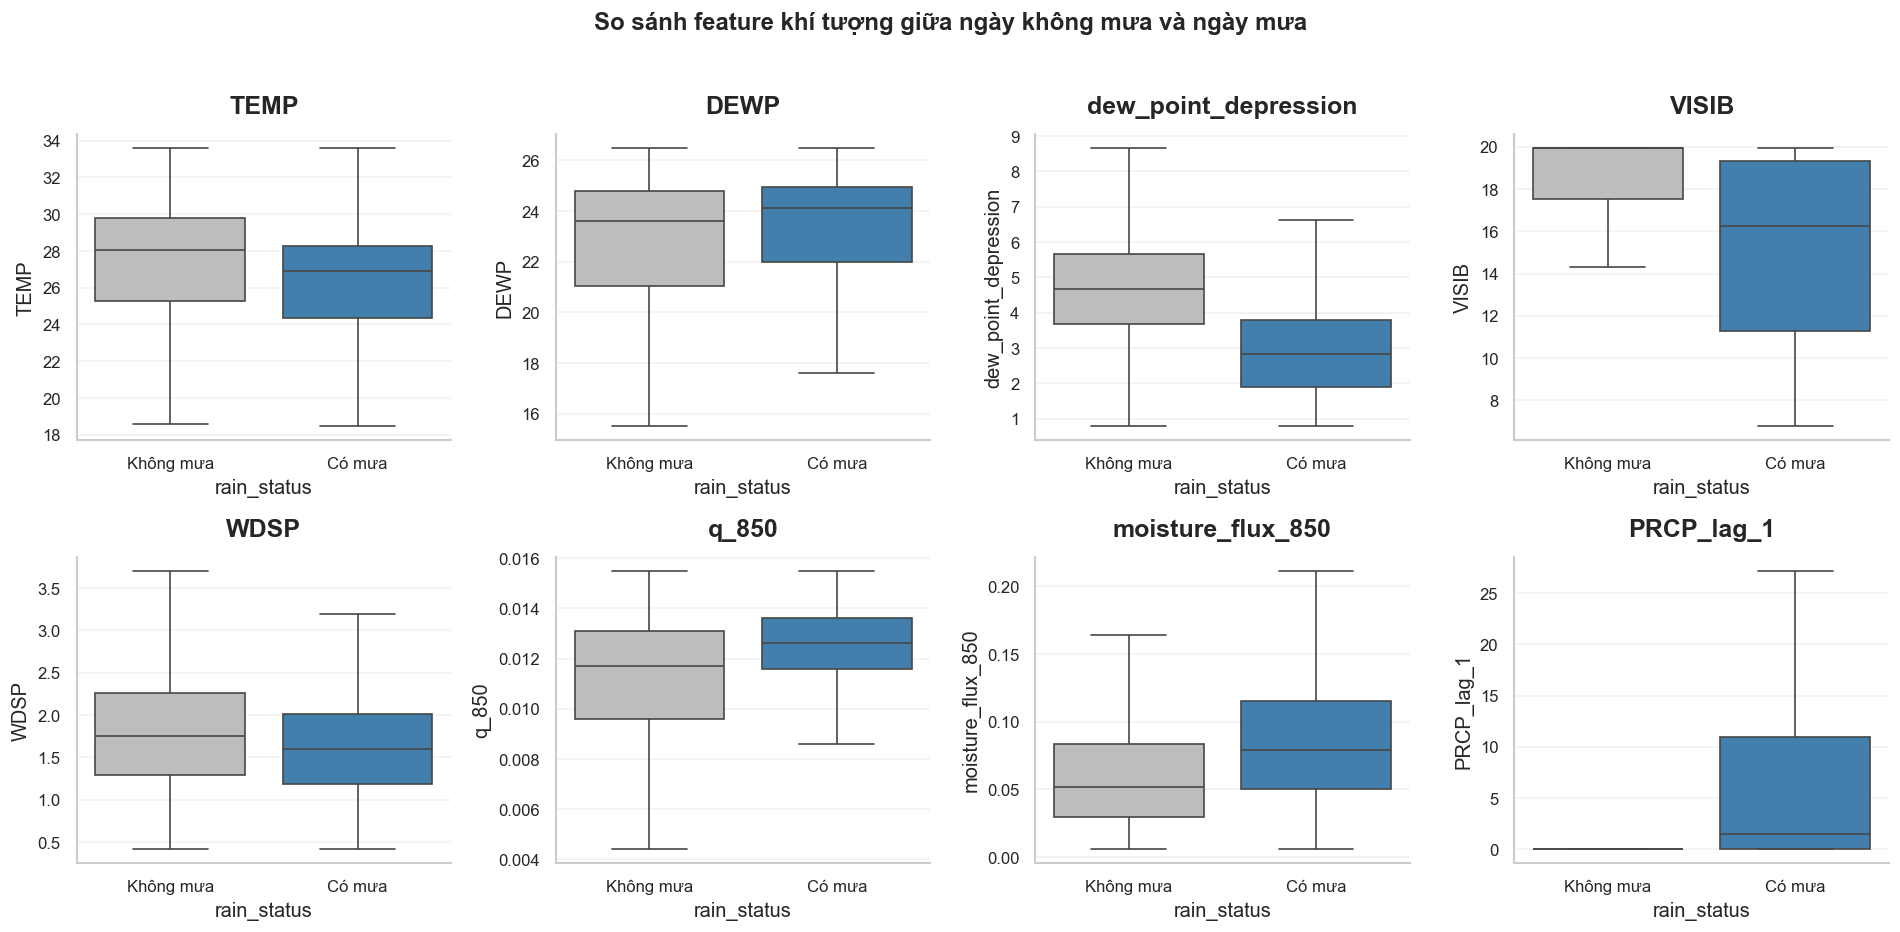

In [37]:
# =============================================================================
# 8. Rain vs non-rain feature comparison
# =============================================================================

focus_features = [
    "TEMP", "DEWP", "dew_point_depression", "VISIB",
    "WDSP", "q_850", "moisture_flux_850", "PRCP_lag_1",
]
focus_features = [c for c in focus_features if c in train_df.columns and pd.api.types.is_numeric_dtype(train_df[c])]

if not focus_features:
    print("Không tìm thấy focus features phù hợp.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(focus_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.8 * n_rows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(focus_features):
        plot_df = train_df[["rain_status", col]].dropna().copy()

        if plot_df.empty:
            axes[i].axis("off")
            continue

        low, high = plot_df[col].quantile([0.01, 0.99])
        plot_df[col] = plot_df[col].clip(low, high)

        sns.boxplot(
            data=plot_df,
            x="rain_status",
            y=col,
            order=["Không mưa", "Có mưa"],
            palette=[DRY_COLOR, RAIN_COLOR],
            showfliers=False,
            ax=axes[i],
        )
        clean_axis(axes[i], col, "", col)

    for j in range(len(focus_features), len(axes)):
        axes[j].axis("off")

    plt.suptitle("So sánh feature khí tượng giữa ngày không mưa và ngày mưa", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 9. Các cặp feature tương quan cao

Mục tiêu:

- Chỉ ra một số cặp biến có tương quan cao để hiểu cấu trúc dữ liệu.
- Không xóa feature tại đây.
- Chọn lọc đặc trưng cuối cùng sẽ làm ở file riêng.

,feature_1,feature_2,abs_corr
0,z,elevation_diff,1.000000
1,LONGITUDE,ELEVATION,1.000000
2,PRCP_past_3d_mean,PRCP_past_3d_sum,1.000000
3,moisture_flux_850_3d_mean,moisture_flux_3d_sum,0.999731
4,SLP_lag_2,SLP_3d_mean,0.993287
5,w_850,moist_convection_850,0.992906
6,TEMP_lag_2,TEMP_3d_mean,0.979367
7,DEWP_lag_2,DEWP_3d_mean,0.973748
8,SLP_lag_1,SLP_3d_mean,0.970204
9,day_cos,month_cos,0.970192


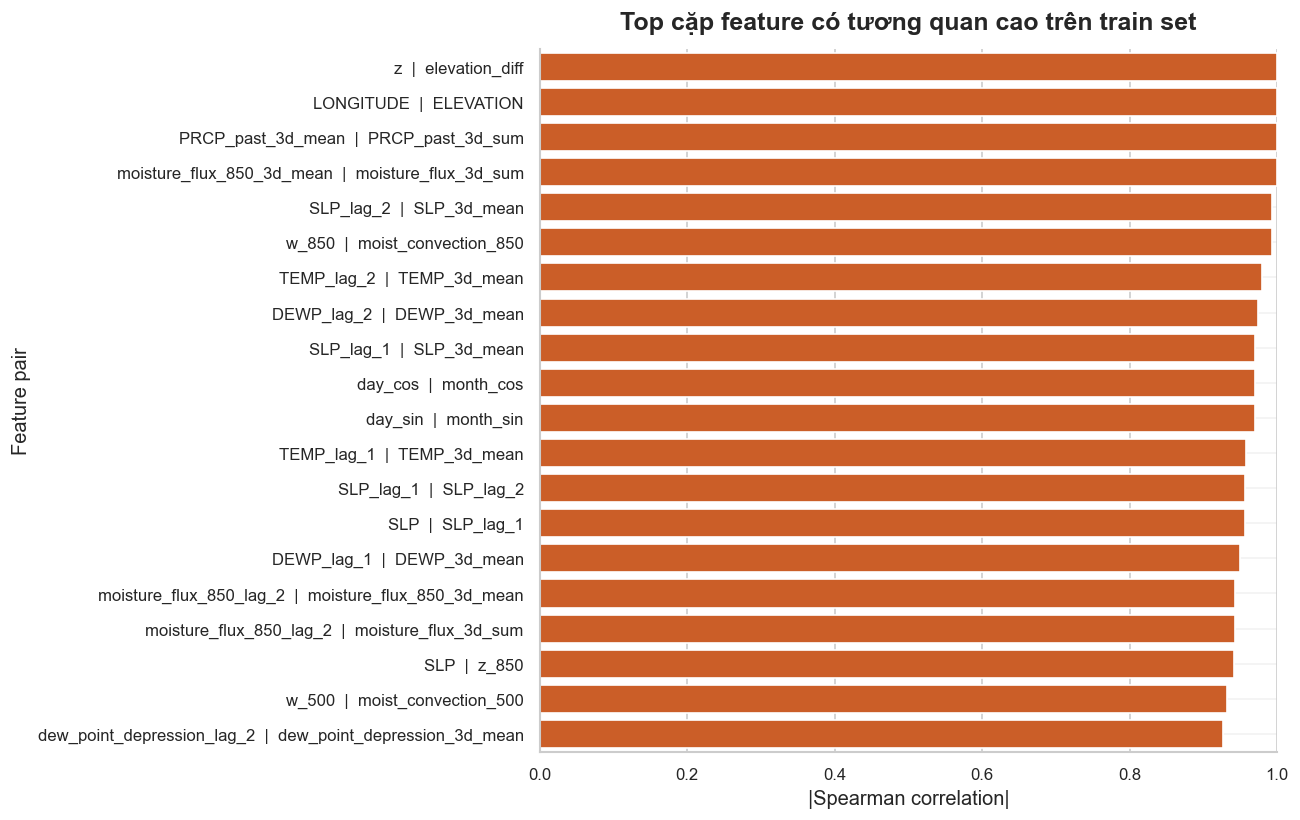

In [38]:
# =============================================================================
# 9. High-correlation feature pairs for EDA only
# =============================================================================

if len(feature_cols) < 2:
    print("Không đủ feature numeric để tính redundancy pairs.")
else:
    redundancy = train_df[feature_cols].corr(method="spearman", numeric_only=True).abs()
    upper = redundancy.where(np.triu(np.ones(redundancy.shape), k=1).astype(bool))

    pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
    )

    pairs.columns = ["feature_1", "feature_2", "abs_corr"]
    pairs["pair"] = pairs["feature_1"] + "  |  " + pairs["feature_2"]

    display(pairs[["feature_1", "feature_2", "abs_corr"]])

    plt.figure(figsize=(11, 7))
    ax = sns.barplot(data=pairs, x="abs_corr", y="pair", color=ORANGE_COLOR)
    ax.set_xlim(0, 1.0)
    clean_axis(ax, "Top cặp feature có tương quan cao trên train set", "|Spearman correlation|", "Feature pair")
    plt.tight_layout()
    plt.show()

## 10. Feature group summary

Mục tiêu:

- Tóm tắt số lượng feature theo nhóm.
- Phục vụ mô tả phần feature engineering trong báo cáo.
- Không thực hiện chọn lọc đặc trưng ở đây.

In [39]:
# =============================================================================
# 10. Feature group summary
# =============================================================================

feature_column_summary = pd.DataFrame(
    [
        {
            "column": col,
            "feature_group": infer_feature_group(col),
            "dtype": str(df_raw[col].dtype),
            "missing_count": int(df_raw[col].isna().sum()),
            "missing_percent": float(df_raw[col].isna().mean() * 100),
            "n_unique": int(df_raw[col].nunique(dropna=True)),
        }
        for col in df_raw.columns
    ]
)

feature_group_summary = (
    feature_column_summary.groupby("feature_group")
    .agg(
        n_columns=("column", "count"),
        avg_missing_percent=("missing_percent", "mean"),
        max_missing_percent=("missing_percent", "max"),
        min_missing_percent=("missing_percent", "min"),
    )
    .reset_index()
    .sort_values(["n_columns", "avg_missing_percent"], ascending=[False, False])
)

display(feature_group_summary)
display(feature_column_summary.head(40))

,feature_group,n_columns,avg_missing_percent,max_missing_percent,min_missing_percent
6,lag_rolling,20,0.035587,0.054750,0.027375
2,era5_pressure_850hpa,18,0.019771,0.054750,0.000000
1,era5_pressure_500hpa,11,0.000000,0.000000,0.000000
0,eda_helper,6,0.336710,2.020257,0.000000
5,gsod_surface,6,0.000000,0.000000,0.000000
10,target_or_auxiliary,5,21.212154,97.979743,2.020257
3,era5_single_level,4,0.000000,0.000000,0.000000
8,metadata_time,4,0.000000,0.000000,0.000000
11,temporal_cyclical,4,0.000000,0.000000,0.000000
7,location,3,0.000000,0.000000,0.000000


,column,feature_group,dtype,missing_count,missing_percent,n_unique
0,STATION,metadata_time,object,0,0.000000,5
1,time,metadata_time,datetime64[ns],0,0.000000,3653
2,LATITUDE,location,float64,0,0.000000,5
3,LONGITUDE,location,float64,0,0.000000,5
4,ELEVATION,location,float64,0,0.000000,5
5,TEMP,gsod_surface,float64,0,0.000000,681
6,PRCP,target_or_auxiliary,float64,369,2.020257,451
7,WDSP,gsod_surface,float64,0,0.000000,724
8,DEWP,gsod_surface,float64,0,0.000000,679
9,STP,gsod_surface,float64,0,0.000000,16953
